In [11]:
!pip install openpyxl
%%time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, auc, precision_recall_fscore_support)
from sklearn.impute import SimpleImputer

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Librerías cargadas correctamente.")

Defaulting to user installation because normal site-packages is not writeable


UsageError: Line magic function `%%time` not found.


In [86]:
%%time

# === RUTA DE TUS DATOS ===
RUTA_RAIZ = "C:\\Users\\Usuario\\Documents\\UD\\Parcial minería 2\\Mineria_de_Datos-1\\Parcial Final\\Events\\Run_198272\\CSV"  # <--- ¡CAMBIA ESTO!
ARCHIVO_CLASIFICADOR = "clasificador.xlsx"

def get_leading_particle_features(df, prefix):
    """
    Busca la partícula con mayor pt y extrae sus datos.
    Retorna un diccionario con pt, eta, phi, charge.
    """
    features = {
        f'{prefix}_exists': 0,
        f'{prefix}_pt': 0.0,
        f'{prefix}_eta': 0.0,
        f'{prefix}_phi': 0.0,
        f'{prefix}_charge': 0.0
    }
    
    if df is not None and not df.empty:
        # Ordenamos por pt descendente y tomamos la primera (Leading Particle)
        leading = df.sort_values(by='pt', ascending=False).iloc[0]
        features[f'{prefix}_exists'] = 1
        features[f'{prefix}_pt'] = leading['pt']
        features[f'{prefix}_eta'] = leading.get('eta', 0.0)
        features[f'{prefix}_phi'] = leading.get('phi', 0.0)
        features[f'{prefix}_charge'] = leading.get('charge', 0.0)
        
    return features

def extract_features_kinematic(event_id, root_path):
    event_path = os.path.join(root_path, f"Event_{event_id}")
    
    # -- 1. ELECTRONES (GsfElectrons_V2) --
    try:
        df_ele = pd.read_csv(os.path.join(event_path, "GsfElectrons_V2.csv"))
    except: df_ele = None
    feat_ele = get_leading_particle_features(df_ele, 'ele')

    # -- 2. MUONES (TrackerMuons_V2) --
    try:
        df_mu = pd.read_csv(os.path.join(event_path, "TrackerMuons_V2.csv"))
    except: df_mu = None
    feat_mu = get_leading_particle_features(df_mu, 'mu')

    # -- 3. MET (PFMETs_V1) --
    # MET no tiene carga ni eta usualmente, solo pt y phi
    feat_met = {'met_pt': 0.0, 'met_phi': 0.0}
    try:
        df_met = pd.read_csv(os.path.join(event_path, "PFMETs_V1.csv"))
        if not df_met.empty:
            feat_met['met_pt'] = df_met['pt'].iloc[0]
            feat_met['met_phi'] = df_met['phi'].iloc[0]
    except: pass
    
    # Unir todo
    return {**feat_ele, **feat_mu, **feat_met}

# === PROCESAMIENTO ===
print("Iniciando carga de datos...")
# Cargar Excel
df_labels = pd.read_excel(ARCHIVO_CLASIFICADOR) if ARCHIVO_CLASIFICADOR.endswith('xlsx') else pd.read_csv(ARCHIVO_CLASIFICADOR)

data_list = []
for idx, row in df_labels.iterrows():
    ev_id = row['Id']
    
    # Extraer
    feats = extract_features_kinematic(ev_id, RUTA_RAIZ)
    
    # Etiquetas (Binarizamos >0 es 1, else 0)
    feats['Z'] = 1 if row['Z'] > 0 else 0
    feats['W+'] = 1 if row['W+'] > 0 else 0
    feats['W-'] = 1 if row['W-'] > 0 else 0
    
    data_list.append(feats)

df_final = pd.DataFrame(data_list)
print(f"Procesados {len(df_final)} eventos.")
print(df_final.head())

Iniciando carga de datos...
Procesados 24 eventos.
   ele_exists   ele_pt  ele_eta  ele_phi  ele_charge  mu_exists    mu_pt  \
0           0  0.00000  0.00000  0.00000         0.0          0  0.00000   
1           0  0.00000  0.00000  0.00000         0.0          0  0.00000   
2           1  2.74298 -1.98662 -1.77508        -1.0          1  1.47235   
3           0  0.00000  0.00000  0.00000         0.0          0  0.00000   
4           0  0.00000  0.00000  0.00000         0.0          0  0.00000   

    mu_eta    mu_phi  mu_charge    met_pt   met_phi  Z  W+  W-  
0  0.00000  0.000000        0.0  22.02880  2.011940  0   0   0  
1  0.00000  0.000000        0.0  31.60000  0.571510  0   0   0  
2  1.52991 -0.225804        1.0  18.56040  0.877615  1   0   1  
3  0.00000  0.000000        0.0   6.85338  0.355623  0   0   0  
4  0.00000  0.000000        0.0  17.51100  2.506140  0   0   0  
CPU times: total: 78.1 ms
Wall time: 67.1 ms


In [87]:
# Prueba con un evento
print("=== PRUEBA DE CORRECCIÓN ===\n")

# Toma el primer evento
event_id = df_labels['Id'].iloc[0]

# Antes de la corrección
old_path = os.path.join(RUTA_RAIZ, str(event_id))
print(f"ANTES (vieja ruta): {old_path}")
print(f"Existe: {os.path.exists(old_path)}")

# Después de la corrección
new_path = os.path.join(RUTA_RAIZ, f"Event_{event_id}")
print(f"\nDESPUÉS (nueva ruta): {new_path}")
print(f"Existe: {os.path.exists(new_path)}")

if os.path.exists(new_path):
    print(f"\nArchivos en la carpeta:")
    for file in os.listdir(new_path):
        print(f"  - {file}")
    
    # Prueba leer un archivo
    csv_path = os.path.join(new_path, "GsfElectrons_V2.csv")
    if os.path.exists(csv_path):
        df_test = pd.read_csv(csv_path)
        print(f"\nContenido de GsfElectrons_V2.csv:")
        print(f"  Shape: {df_test.shape}")
        print(f"  Columnas: {df_test.columns.tolist()}")
        if not df_test.empty:
            print(f"  Primera fila:\n{df_test.iloc[0]}")

=== PRUEBA DE CORRECCIÓN ===

ANTES (vieja ruta): C:\Users\Usuario\Documents\UD\Parcial minería 2\Mineria_de_Datos-1\Parcial Final\Events\Run_198272\CSV\272621358
Existe: False

DESPUÉS (nueva ruta): C:\Users\Usuario\Documents\UD\Parcial minería 2\Mineria_de_Datos-1\Parcial Final\Events\Run_198272\CSV\Event_272621358
Existe: True

Archivos en la carpeta:
  - EBRecHits_V2.csv
  - EERecHits_V2.csv
  - ESRecHits_V2.csv
  - Event_V2.csv
  - Extras_V1.csv
  - GlobalMuons_V1.csv
  - GsfElectrons_V2.csv
  - HBRecHits_V2.csv
  - HERecHits_V2.csv
  - HFRecHits_V2.csv
  - HORecHits_V2.csv
  - PFJets_V1.csv
  - PFMETs_V1.csv
  - PFTaus_V1.csv
  - Photons_V1.csv
  - Products_V1.csv
  - RecHitFractions_V1.csv
  - StandaloneMuons_V2.csv
  - SuperClusters_V1.csv
  - TrackerMuons_V1.csv
  - TrackerMuons_V2.csv
  - Tracks_V3.csv
  - TriggerObjects_V1.csv
  - TriggerPaths_V1.csv
  - Vertices_V1.csv

Contenido de GsfElectrons_V2.csv:
  Shape: (0, 10)
  Columnas: ['pt', 'eta', 'phi', 'charge', 'pos_x', 'p

In [100]:
%%time

from sklearn.model_selection import StratifiedShuffleSplit

# Verificar si alguna clase no tiene suficientes ejemplos
min_samples = y.sum().min()
print(f"Mínimo de ejemplos por clase: {min_samples}")

# Si alguna clase tiene muy pocos ejemplos, usar muestreo estratificado
if min_samples < 3:
    print("Advertencia: Algunas clases tienen muy pocos ejemplos. Considerar:")
    print("1. Usar test_size más grande (0.5 o 0.6)")
    print("2. Usar validación cruzada")
    print("3. Balancear manualmente el conjunto de datos")

# Definir columnas de features y targets
feature_cols = [col for col in df_final.columns if col not in ['Z', 'W+', 'W-']]
target_cols = ['Z', 'W+', 'W-']

X = df_final[feature_cols]
y = df_final[target_cols]

# Ver distribución de etiquetas
print("Distribución de etiquetas en el conjunto total:")
print(y.sum())

# Elegir la etiqueta con más ejemplos para estratificar
stratify_column = y.sum().idxmax()
print(f"Estratificando por {stratify_column}")

# División 80-20 (ajustado a 50% por el código original)
# Ahora con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y[stratify_column]  # ¡AÑADIR ESTA LÍNEA!
)

# Ver distribución en el conjunto de prueba
print("\nDistribución de etiquetas en el conjunto de prueba:")
print(y_test.sum())

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos listos para entrenamiento.")

Mínimo de ejemplos por clase: 2
Advertencia: Algunas clases tienen muy pocos ejemplos. Considerar:
1. Usar test_size más grande (0.5 o 0.6)
2. Usar validación cruzada
3. Balancear manualmente el conjunto de datos
Distribución de etiquetas en el conjunto total:
Z     7
W+    2
W-    9
dtype: int64
Estratificando por W-

Distribución de etiquetas en el conjunto de prueba:
Z     2
W+    0
W-    2
dtype: int64

Datos listos para entrenamiento.
CPU times: total: 0 ns
Wall time: 6.52 ms


In [101]:
print("=== ANÁLISIS DE DISTRIBUCIÓN ===")
print("\nDistribución total:")
print(y.sum())

print("\nDistribución en entrenamiento:")
print(y_train.sum())

print("\nDistribución en prueba:")
print(y_test.sum())

print("\nPorcentajes en entrenamiento:")
print((y_train.sum() / len(y_train) * 100).round(2))

print("\nPorcentajes en prueba:")
print((y_test.sum() / len(y_test) * 100).round(2))

=== ANÁLISIS DE DISTRIBUCIÓN ===

Distribución total:
Z     7
W+    2
W-    9
dtype: int64

Distribución en entrenamiento:
Z     5
W+    2
W-    7
dtype: int64

Distribución en prueba:
Z     2
W+    0
W-    2
dtype: int64

Porcentajes en entrenamiento:
Z     26.32
W+    10.53
W-    36.84
dtype: float64

Porcentajes en prueba:
Z     40.0
W+     0.0
W-    40.0
dtype: float64


In [102]:
%%time

# Configuramos Regresión Logística
# n_jobs=-1 usa todos los núcleos del procesador
clf = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))

print("Entrenando modelo...")
clf.fit(X_train_scaled, y_train)
print("Entrenamiento completado.")

# Predecir probabilidades y clases
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

Entrenando modelo...
Entrenamiento completado.
CPU times: total: 0 ns
Wall time: 8.03 ms


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           Z       0.00      0.00      0.00         2
          W+       0.00      0.00      0.00         0
          W-       0.67      1.00      0.80         2

   micro avg       0.50      0.50      0.50         4
   macro avg       0.22      0.33      0.27         4
weighted avg       0.33      0.50      0.40         4
 samples avg       0.40      0.40      0.40         4



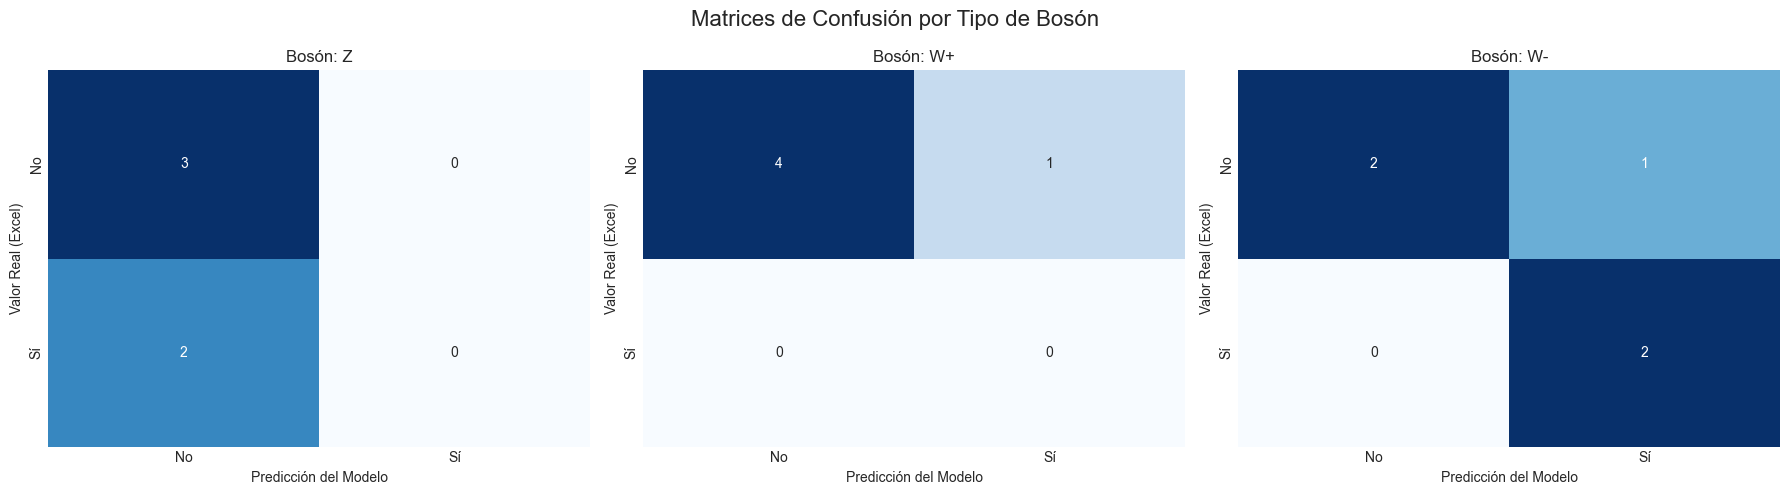

CPU times: total: 188 ms
Wall time: 187 ms


In [103]:
%%time

# Reporte numérico
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=target_cols, zero_division=0))

# Matrices de Confusión Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(target_cols):
    # Añadir labels=[0, 1] para forzar matriz 2x2
    cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i], labels=[0, 1])

    # Mapa de calor - especificar xticklabels y yticklabels directamente en heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
    axes[i].set_title(f'Bosón: {label}')
    axes[i].set_xlabel('Predicción del Modelo')
    axes[i].set_ylabel('Valor Real (Excel)')

plt.suptitle('Matrices de Confusión por Tipo de Bosón', fontsize=16)
plt.tight_layout()
plt.show()

Advertencia: No hay ejemplos positivos para W+ en el conjunto de prueba. Omitiendo curva ROC.


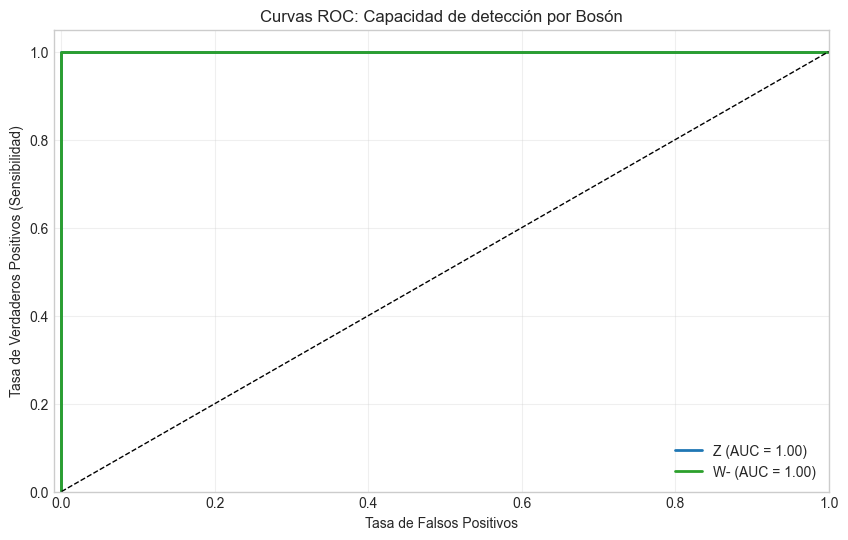

CPU times: total: 78.1 ms
Wall time: 80.3 ms


In [104]:
%%time

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Colores distintivos

for i, label in enumerate(target_cols):
    # Verificar si hay ejemplos positivos en el conjunto de prueba para esta etiqueta
    if y_test.iloc[:, i].sum() == 0:
        print(f"Advertencia: No hay ejemplos positivos para {label} en el conjunto de prueba. Omitiendo curva ROC.")
        continue  # Saltar a la siguiente iteración si no hay positivos
    
    # Si hay positivos, calcular la curva ROC normalmente
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1) # Línea aleatoria
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC: Capacidad de detección por Bosón')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

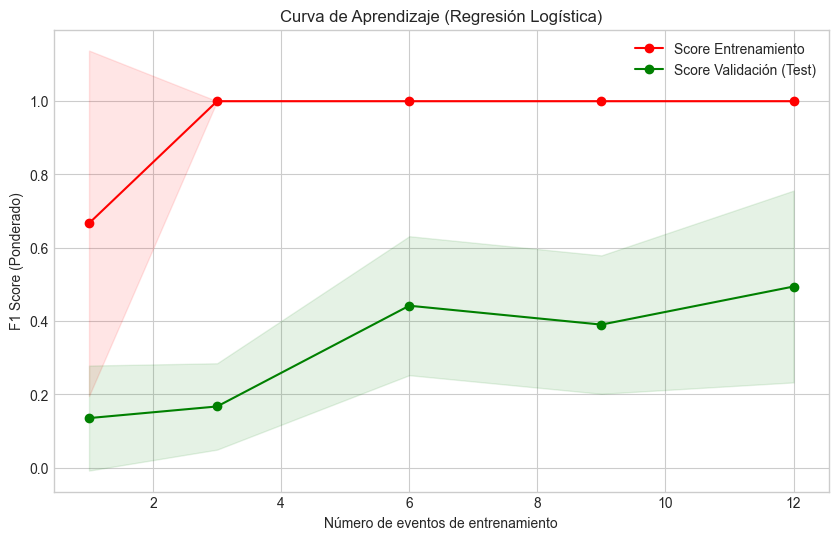

CPU times: total: 93.8 ms
Wall time: 126 ms


In [105]:
%%time

def plot_learning_curve_graph(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='f1_weighted' # Usamos F1 score ponderado
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score Entrenamiento")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Score Validación (Test)")
    
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
    
    plt.title("Curva de Aprendizaje (Regresión Logística)")
    plt.xlabel("Número de eventos de entrenamiento")
    plt.ylabel("F1 Score (Ponderado)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve_graph(clf, X_train_scaled, y_train)

In [106]:
# Importamos las librerías específicas para Árboles de Decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

print("Librerías de Árboles de Decisión cargadas.")

Librerías de Árboles de Decisión cargadas.


In [107]:
%%time

# Configuramos el Árbol de Decisión
# max_depth=5: Limitamos la profundidad para evitar sobreajuste dado que tenemos pocos datos
# class_weight='balanced': Ayuda si hay desbalance de clases (como W+ que tiene pocos ejemplos)
tree_model = OneVsRestClassifier(DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42,
    class_weight='balanced' 
))

print("Entrenando Árbol de Decisión...")
tree_model.fit(X_train_scaled, y_train)
print("Entrenamiento completado.")

# Predecir probabilidades y clases
y_pred_tree = tree_model.predict(X_test_scaled)
y_prob_tree = tree_model.predict_proba(X_test_scaled)

Entrenando Árbol de Decisión...
Entrenamiento completado.
CPU times: total: 15.6 ms
Wall time: 16 ms


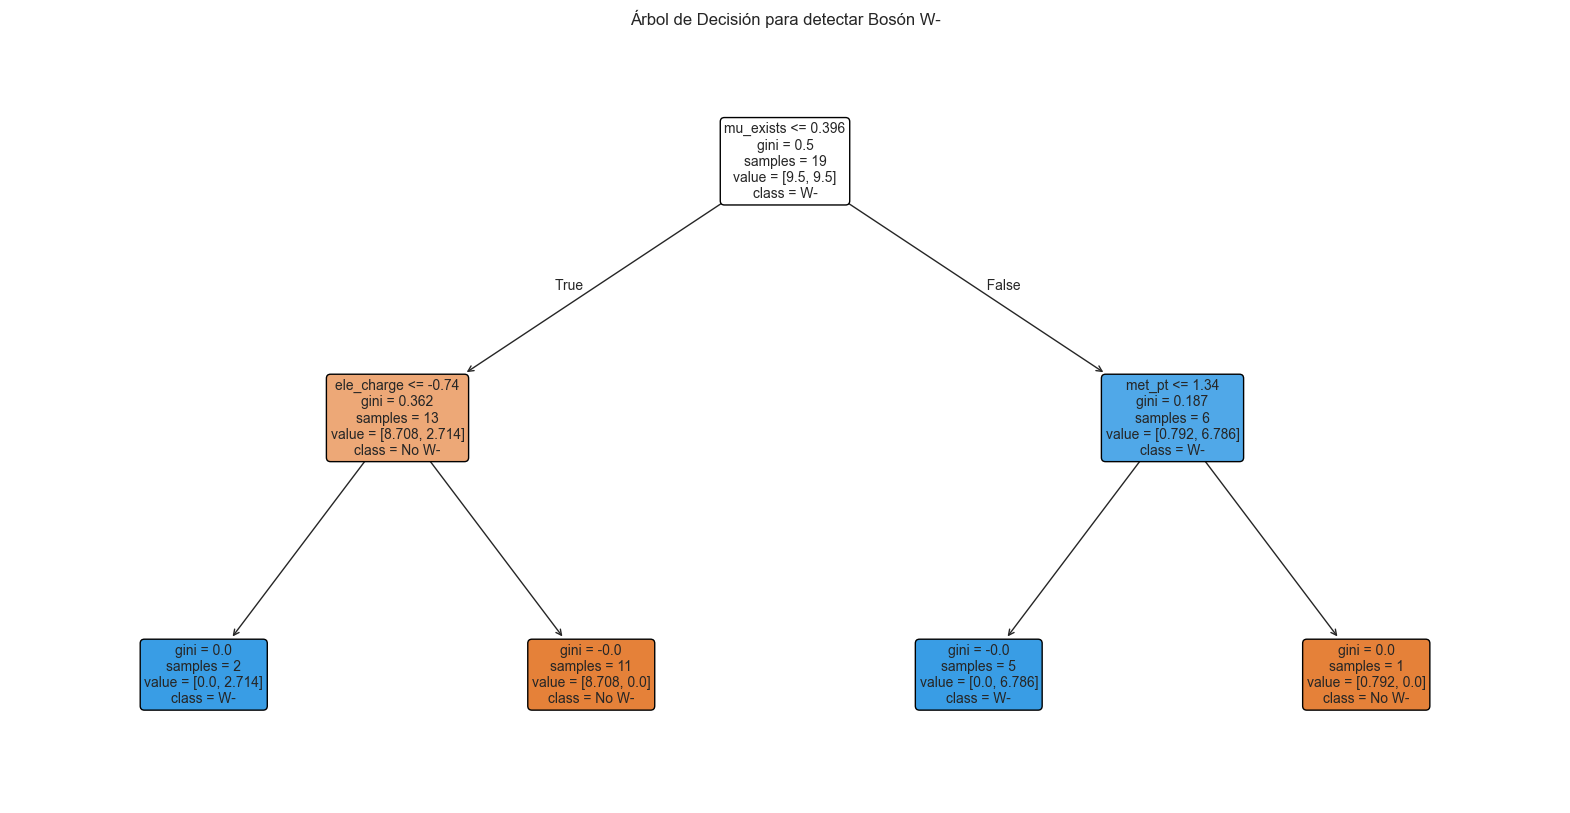

--- Reglas para W- ---
|--- mu_exists <= 0.40
|   |--- ele_charge <= -0.74
|   |   |--- class: 1
|   |--- ele_charge >  -0.74
|   |   |--- class: 0
|--- mu_exists >  0.40
|   |--- met_pt <= 1.34
|   |   |--- class: 1
|   |--- met_pt >  1.34
|   |   |--- class: 0



In [108]:
# Visualización del árbol para la clase W- (índice 2)
# Puedes cambiar estimator_idx a 0 (Z) o 1 (W+) para ver los otros
estimator_idx = 2 
target_name = target_cols[estimator_idx]

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model.estimators_[estimator_idx], 
    feature_names=feature_cols,
    class_names=['No ' + target_name, target_name],
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title(f"Árbol de Decisión para detectar Bosón {target_name}")
plt.show()

# También imprimimos las reglas en texto para mayor claridad
print(f"--- Reglas para {target_name} ---")
print(export_text(tree_model.estimators_[estimator_idx], feature_names=feature_cols))

=== Reporte de Clasificación (Árboles de Decisión) ===
              precision    recall  f1-score   support

           Z       1.00      0.50      0.67         2
          W+       0.00      0.00      0.00         0
          W-       0.67      1.00      0.80         2

   micro avg       0.60      0.75      0.67         4
   macro avg       0.56      0.50      0.49         4
weighted avg       0.83      0.75      0.73         4
 samples avg       0.50      0.60      0.53         4



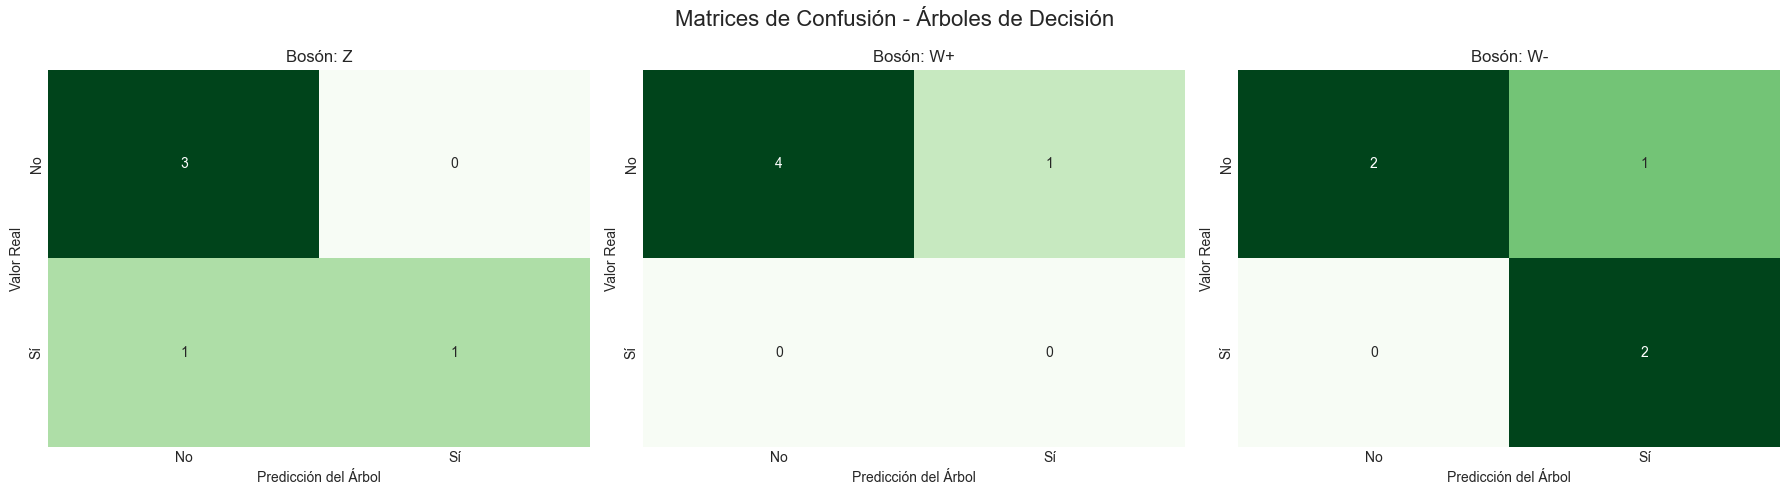

CPU times: total: 188 ms
Wall time: 186 ms


In [109]:
%%time

# Reporte numérico
print("=== Reporte de Clasificación (Árboles de Decisión) ===")
print(classification_report(y_test, y_pred_tree, target_names=target_cols, zero_division=0))

# Matrices de Confusión Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(target_cols):
    # Añadir labels=[0, 1] para forzar matriz 2x2 aunque falten clases en el test
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_tree[:, i], labels=[0, 1])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
    axes[i].set_title(f'Bosón: {label}')
    axes[i].set_xlabel('Predicción del Árbol')
    axes[i].set_ylabel('Valor Real')

plt.suptitle('Matrices de Confusión - Árboles de Decisión', fontsize=16)
plt.tight_layout()
plt.show()

Advertencia: No hay ejemplos positivos para W+ en el test. Omitiendo curva ROC.


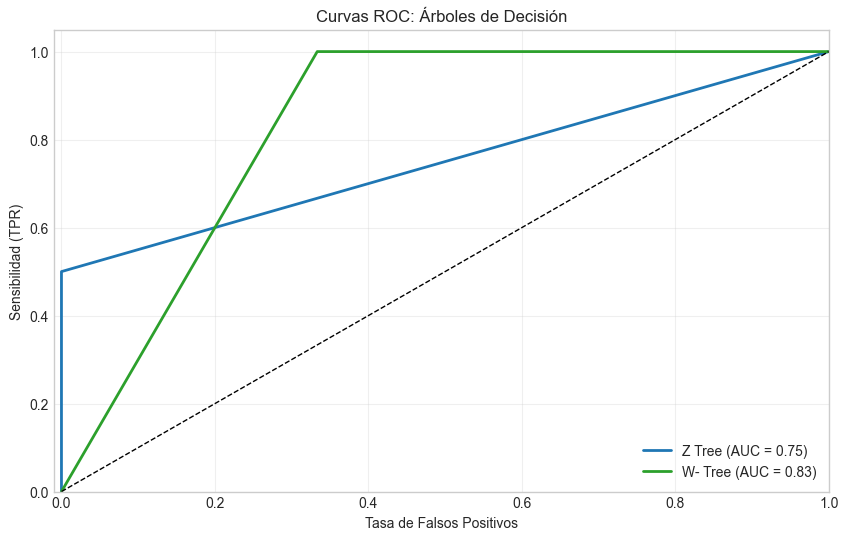

CPU times: total: 78.1 ms
Wall time: 79.1 ms


In [113]:
%%time

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, label in enumerate(target_cols):
    if y_test.iloc[:, i].sum() == 0:
        print(f"Advertencia: No hay ejemplos positivos para {label} en el test. Omitiendo curva ROC.")
        continue
    
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_tree[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Usamos línea sólida para distinguir del modelo anterior
    plt.plot(fpr, tpr, color=colors[i], lw=2, linestyle='-', label=f'{label} Tree (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curvas ROC: Árboles de Decisión')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

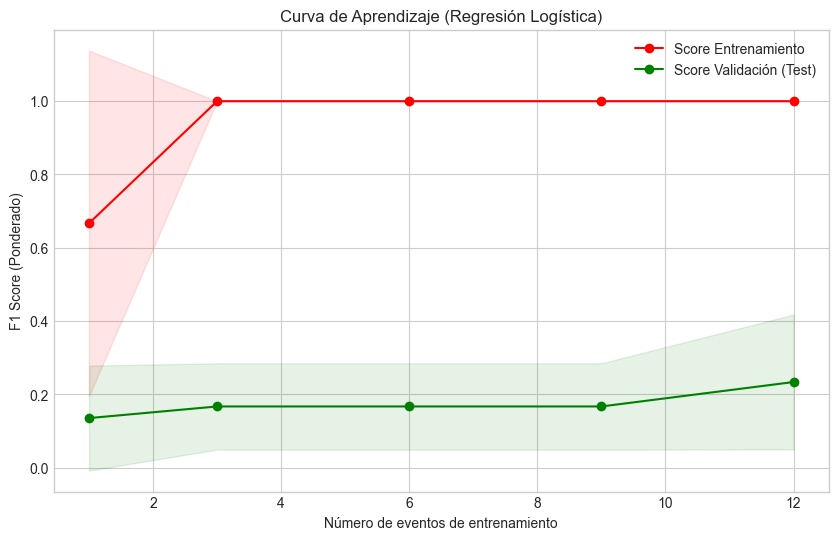

In [111]:
# Reutilizamos la función plot_learning_curve_graph definida en tu notebook anterior
# pero pasamos el nuevo modelo de árboles
plot_learning_curve_graph(tree_model, X_train_scaled, y_train)

In [114]:
# Importamos la librería específica para Vecinos más Cercanos
from sklearn.neighbors import KNeighborsClassifier

print("Librerías de KNN cargadas.")

Librerías de KNN cargadas.


In [115]:
%%time

# Configuramos KNN
# n_neighbors=3: Mira los 3 eventos más parecidos históricamente para decidir.
# metric='euclidean': Usa la distancia estándar (línea recta en el espacio de características).
knn_model = OneVsRestClassifier(KNeighborsClassifier(
    n_neighbors=3, 
    metric='euclidean',
    weights='distance' # Los vecinos más cercanos tienen más peso en la decisión
))

print("Entrenando KNN...")
knn_model.fit(X_train_scaled, y_train)
print("Entrenamiento completado.")

# Predecir probabilidades y clases
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)

Entrenando KNN...
Entrenamiento completado.
CPU times: total: 15.6 ms
Wall time: 9.71 ms


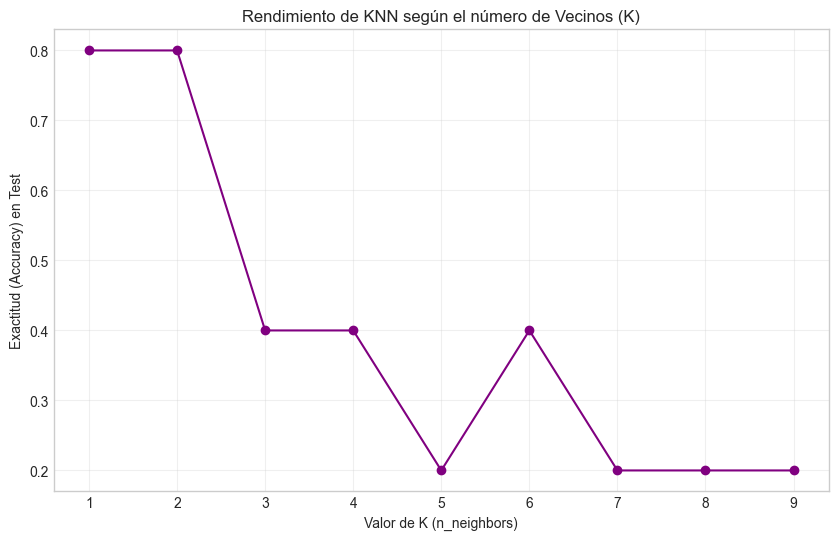

El K actual usado en el modelo principal es: 3


In [116]:
# Vamos a probar varios valores de K para ver cuál funciona mejor
k_range = range(1, 10) # Probamos de 1 a 9 vecinos
scores = []

for k in k_range:
    # Entrenamos un KNN temporal para cada k
    temp_knn = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=k, weights='distance'))
    temp_knn.fit(X_train_scaled, y_train)
    # Guardamos el score (precisión promedio) en el set de prueba
    scores.append(temp_knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linestyle='-', color='purple')
plt.title('Rendimiento de KNN según el número de Vecinos (K)')
plt.xlabel('Valor de K (n_neighbors)')
plt.ylabel('Exactitud (Accuracy) en Test')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

print(f"El K actual usado en el modelo principal es: 3")

=== Reporte de Clasificación (KNN) ===
              precision    recall  f1-score   support

           Z       0.00      0.00      0.00         2
          W+       0.00      0.00      0.00         0
          W-       1.00      0.50      0.67         2

   micro avg       1.00      0.25      0.40         4
   macro avg       0.33      0.17      0.22         4
weighted avg       0.50      0.25      0.33         4
 samples avg       0.20      0.20      0.20         4



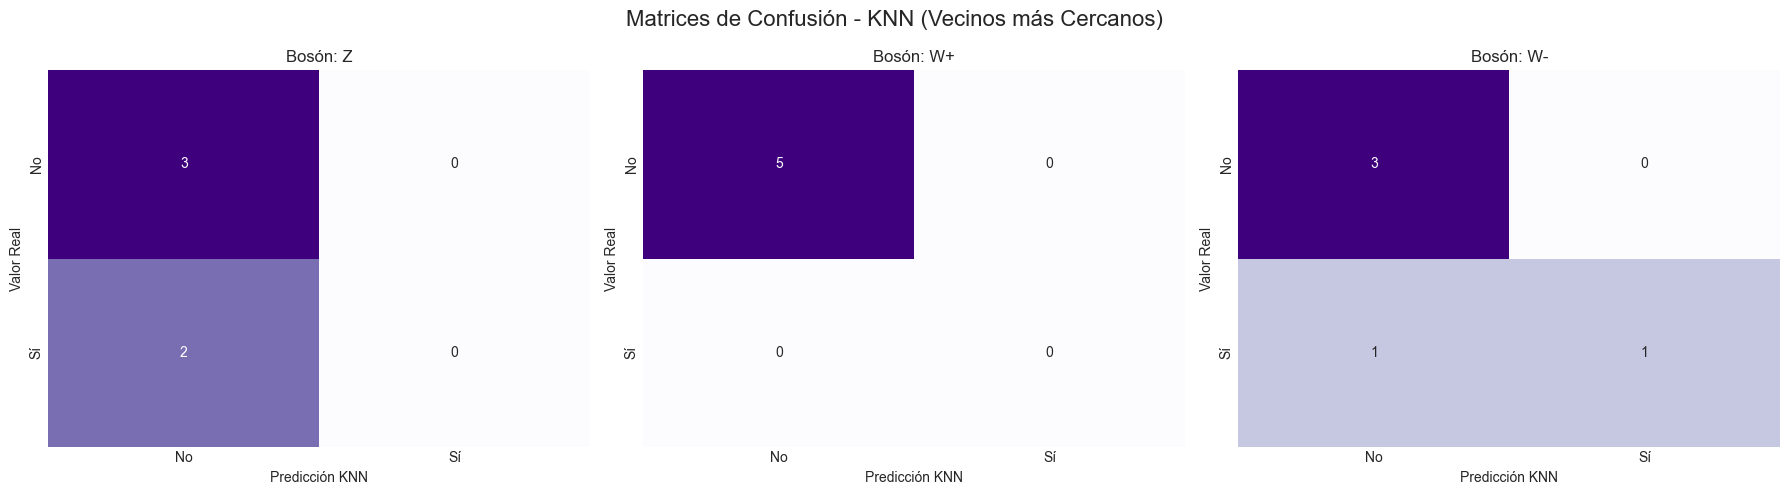

CPU times: total: 188 ms
Wall time: 188 ms


In [117]:
%%time

# Reporte numérico
print("=== Reporte de Clasificación (KNN) ===")
print(classification_report(y_test, y_pred_knn, target_names=target_cols, zero_division=0))

# Matrices de Confusión Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(target_cols):
    # Forzar matriz 2x2
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_knn[:, i], labels=[0, 1])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[i], cbar=False,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
    axes[i].set_title(f'Bosón: {label}')
    axes[i].set_xlabel('Predicción KNN')
    axes[i].set_ylabel('Valor Real')

plt.suptitle('Matrices de Confusión - KNN (Vecinos más Cercanos)', fontsize=16)
plt.tight_layout()
plt.show()

Advertencia: No hay ejemplos positivos para W+ en el test. Omitiendo curva ROC.


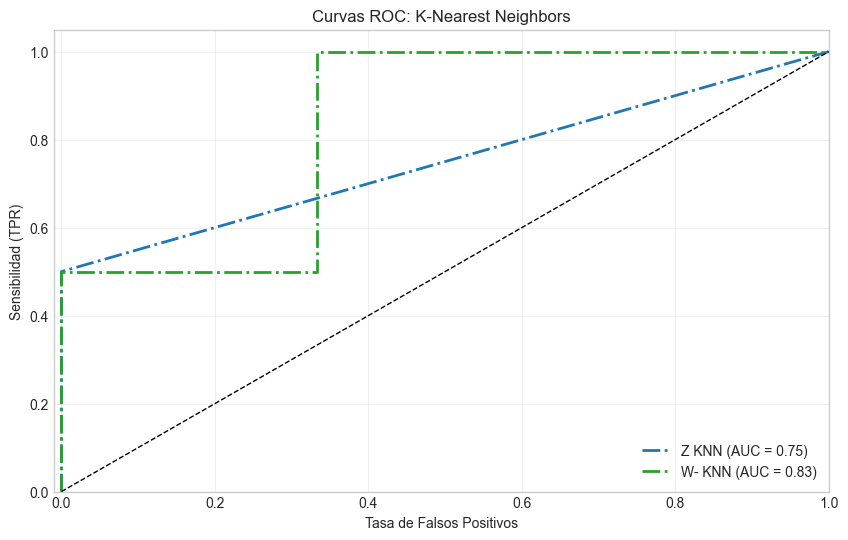

CPU times: total: 78.1 ms
Wall time: 77.7 ms


In [119]:
%%time

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, label in enumerate(target_cols):
    if y_test.iloc[:, i].sum() == 0:
        print(f"Advertencia: No hay ejemplos positivos para {label} en el test. Omitiendo curva ROC.")
        continue
    
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_knn[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2, linestyle='-.', label=f'{label} KNN (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curvas ROC: K-Nearest Neighbors')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

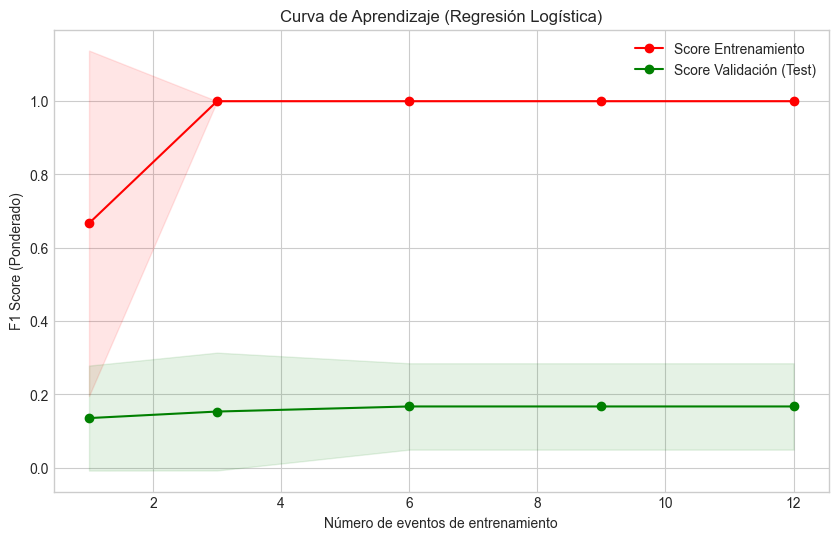

In [120]:
# Reutilizamos la función plot_learning_curve_graph definida anteriormente
plot_learning_curve_graph(knn_model, X_train_scaled, y_train)

In [121]:
# Importamos la librería de Bosques Aleatorios
from sklearn.ensemble import RandomForestClassifier

print("Librerías de Random Forest cargadas.")

Librerías de Random Forest cargadas.


In [122]:
%%time

# Configuramos Random Forest
rf_model = OneVsRestClassifier(RandomForestClassifier(
    n_estimators=100,      # Número de árboles en el bosque
    criterion='gini',
    max_depth=10,          # Profundidad máxima para controlar sobreajuste
    random_state=42,
    class_weight='balanced', # Importante por el desbalance de clases
    n_jobs=-1              # Usar todos los núcleos del procesador
))

print("Entrenando Random Forest (comité de 100 árboles)...")
rf_model.fit(X_train_scaled, y_train)
print("Entrenamiento completado.")

# Predecir probabilidades y clases
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)

Entrenando Random Forest (comité de 100 árboles)...
Entrenamiento completado.
CPU times: total: 406 ms
Wall time: 410 ms


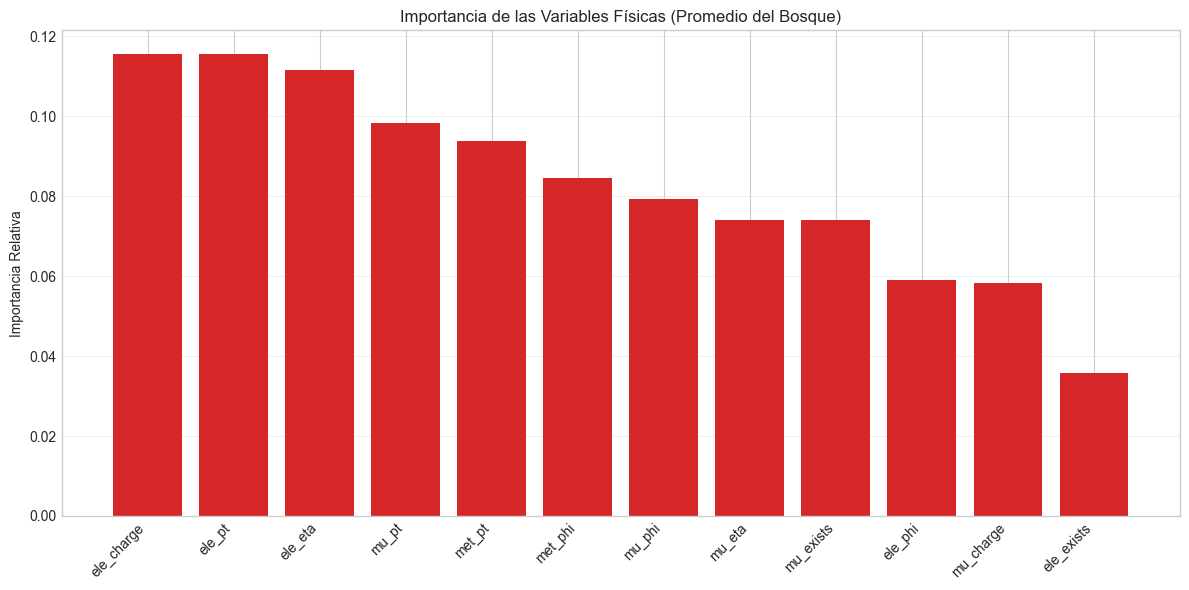

La variable más determinante es: ele_charge


In [123]:
# Extraemos la importancia de las características de cada uno de los 3 estimadores (Z, W+, W-)
importances = np.mean([est.feature_importances_ for est in rf_model.estimators_], axis=0)
indices = np.argsort(importances)[::-1] # Ordenar de mayor a menor importancia

# Graficamos
plt.figure(figsize=(12, 6))
plt.title("Importancia de las Variables Físicas (Promedio del Bosque)")
plt.bar(range(X.shape[1]), importances[indices], color="#d62728", align="center")
plt.xticks(range(X.shape[1]), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.ylabel("Importancia Relativa")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("La variable más determinante es:", feature_cols[indices[0]])

=== Reporte de Clasificación (Random Forest) ===
              precision    recall  f1-score   support

           Z       0.00      0.00      0.00         2
          W+       0.00      0.00      0.00         0
          W-       0.00      0.00      0.00         2

   micro avg       0.00      0.00      0.00         4
   macro avg       0.00      0.00      0.00         4
weighted avg       0.00      0.00      0.00         4
 samples avg       0.00      0.00      0.00         4



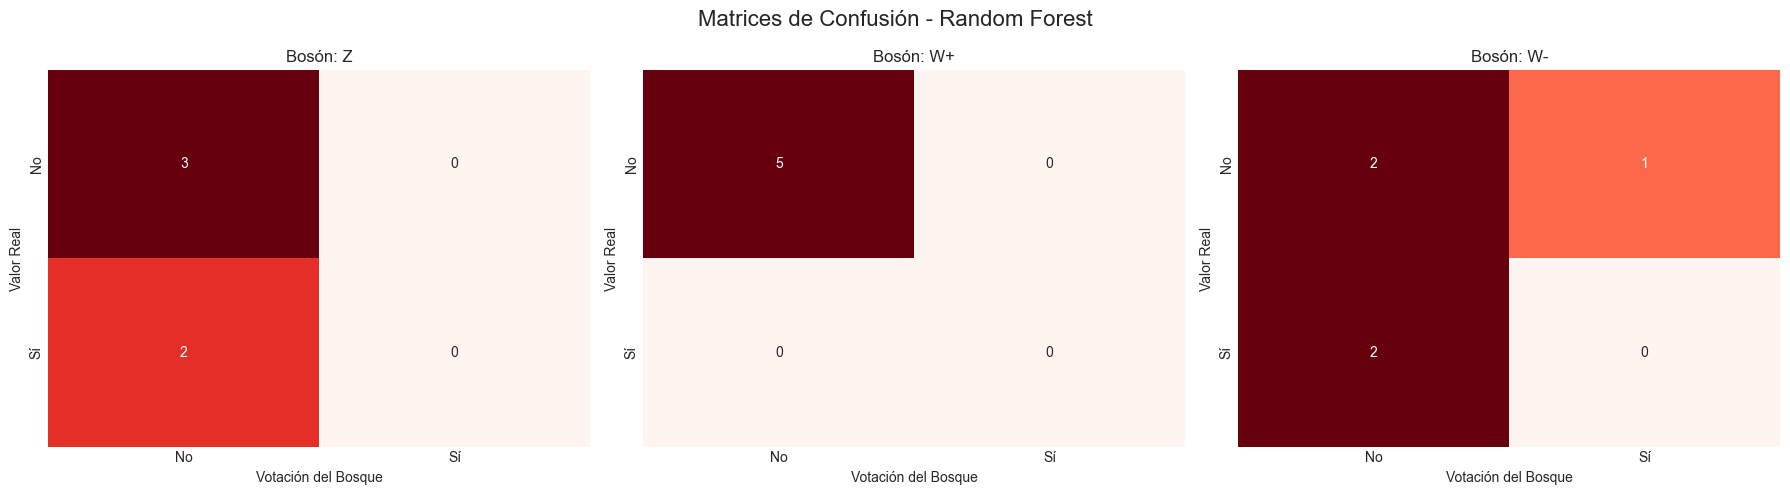

CPU times: total: 172 ms
Wall time: 186 ms


In [124]:
%%time

# Reporte numérico
print("=== Reporte de Clasificación (Random Forest) ===")
print(classification_report(y_test, y_pred_rf, target_names=target_cols, zero_division=0))

# Matrices de Confusión Gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(target_cols):
    # Forzar matriz 2x2
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_rf[:, i], labels=[0, 1])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i], cbar=False,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
    axes[i].set_title(f'Bosón: {label}')
    axes[i].set_xlabel('Votación del Bosque')
    axes[i].set_ylabel('Valor Real')

plt.suptitle('Matrices de Confusión - Random Forest', fontsize=16)
plt.tight_layout()
plt.show()

Advertencia: No hay ejemplos positivos para W+ en el test. Omitiendo curva ROC.


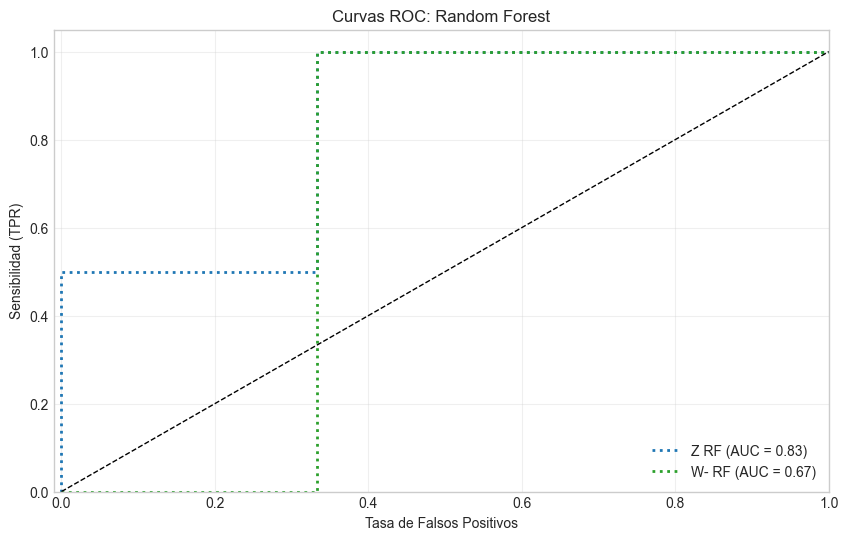

CPU times: total: 78.1 ms
Wall time: 81 ms


In [126]:
%%time

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for i, label in enumerate(target_cols):
    if y_test.iloc[:, i].sum() == 0:
        print(f"Advertencia: No hay ejemplos positivos para {label} en el test. Omitiendo curva ROC.")
        continue
    
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Línea punteada densa para distinguir
    plt.plot(fpr, tpr, color=colors[i], lw=2, linestyle=':', label=f'{label} RF (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curvas ROC: Random Forest')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

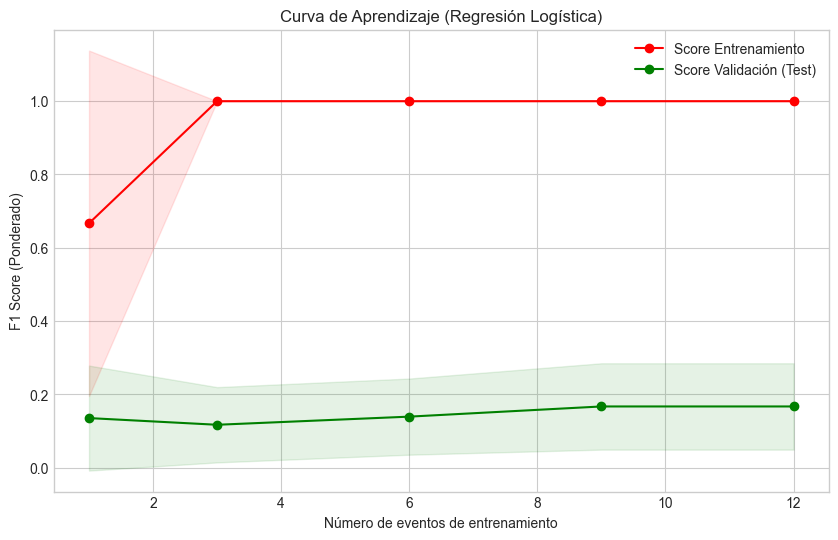

In [127]:
# Reutilizamos la función plot_learning_curve_graph definida anteriormente
plot_learning_curve_graph(rf_model, X_train_scaled, y_train)